In [ ]:
%cd /content
!git clone https://github.com/Matiata/maxim.git
%cd /content/maxim
!pip install -r requirements.txt
!pip install -e .
# %rm -rf /content/maxim

/content
Cloning into 'maxim'...
remote: Enumerating objects: 311, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 311 (delta 146), reused 142 (delta 85), pack-reused 100 (from 1)
Receiving objects: 100% (311/311), 17.26 MiB | 22.03 MiB/s, done.
Resolving deltas: 100% (174/174), done.
/content/maxim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0

In [ ]:
from google.colab import drive # works only for colab
drive.mount('/content/gdrive/',)

Mounted at /content/gdrive/


In [ ]:
import importlib
import collections
import ml_collections
import io
import os
import jax.numpy as jnp
import numpy as np
import tensorflow as tf
import functools
import jax
from jax import random
from PIL import Image
from flax.core import freeze, unfreeze
from flax.traverse_util import flatten_dict, unflatten_dict
from flax.training import train_state, checkpoints
from typing import Any, Callable, Sequence, Tuple, Dict
import optax
from absl import logging

# Runtime configuration

In [ ]:
# Constants
BATCH_SIZE = 2
NUM_EPOCHS = 30
LEARNING_RATE = 2e-4
WARMUP_EPOCHS = 3
PATCH_SIZE = 256
LOG_EVERY = 10
SAVE_EVERY = 2
SEED = 42
NUM_EXPERTS = 5
STEPS_PER_EPOCH = 2000
OUTPUT_DIR = "/content/gdrive/MyDrive/Facultad/tesis/ckpts/moe_training"
DATASET_DIR = "/content/maxim/dataset"
CKPT_PATH = "/content/gdrive/MyDrive/Facultad/tesis/ckpts/ckpt_Enhancement_LOL.npz"
TASK = "enhance"
_MODEL_CONFIGS = {
    "variant": "",
    "dropout_rate": 0.0,
    "num_outputs": 3,
    "use_bias": True,
    "num_supervision_scales": 3,
}
_MODEL_VARIANT_DICT = {
    "denoise": "S-3",
    "deblur": "S-3",
    "derain": "S-2",
    "dehaze": "S-2",
    "enhance": "S-2",
}
SAMPLING_MODE = "uniform"
TASK_DIRS = [
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/derain",
    "/content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/enhance",
]

# Trainer helpers

In [ ]:
class TrainState(train_state.TrainState):
    """Extended train state with batch statistics."""

    batch_stats: Any = None


def resize_to_match(image, target):
    """Resize image to match target dimensions using padding."""
    h, w = image.shape[0], image.shape[1]
    th, tw = target.shape[0], target.shape[1]

    # Check for transposed dimensions
    if h == tw and w == th:
        image = np.rot90(image)

    # Pad if smaller
    pad_h = max(0, th - h)
    pad_w = max(0, tw - w)
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')

    # Crop if bigger
    if h > th or w > tw:
        # Center crop
        top = (h - th) // 2
        left = (w - tw) // 2
        image = image[top:top+th, left:left+tw]

    return image


def random_crop(image, target, crop_size):
    """
    Random crop with security padding if the image is smaller than the crop size.
    Also check target shape, in some cases train/GT are mixed in verical/horizontal format.
    """
    h_i, w_i = image.shape[0], image.shape[1]
    h_t, w_t = target.shape[0], target.shape[1]

    # 1. Calculate necessary padding if the image is smaller than the crop
    pad_h_i = max(0, crop_size - h_i)
    pad_w_i = max(0, crop_size - w_i)
    pad_h_t = max(0, crop_size - h_t)
    pad_w_t = max(0, crop_size - w_t)

    if pad_h_i > 0 or pad_w_i > 0:
        print("padding image", pad_h_i, pad_w_i)
        # Use reflect padding to avoid black borders
        image = np.pad(image, ((0, pad_h_i), (0, pad_w_i), (0, 0)), mode="reflect")
        # Actualizamos dimensiones
        h_i, w_i = image.shape[0], image.shape[1]
    if pad_h_t > 0 or pad_w_t > 0:
        print("padding target", pad_h_t, pad_w_t)
        target = np.pad(target, ((0, pad_h_t), (0, pad_w_t), (0, 0)), mode="reflect")
        # Actualizamos dimensiones
        h_t, w_t = target.shape[0], target.shape[1]

    # 2. Crop: a SINGLE (top, left) shared by image and target so both patches
    #    stay spatially aligned.
    h = min(h_i, h_t)
    w = min(w_i, w_t)
    top = np.random.randint(0, h - crop_size + 1)
    left = np.random.randint(0, w - crop_size + 1)
    image = image[top : top + crop_size, left : left + crop_size]
    target = target[top : top + crop_size, left : left + crop_size]

    return image, target


def random_flip(image, target):
    """Random horizontal and vertical flip."""
    if np.random.rand() > 0.5:
        image = np.fliplr(image)
        target = np.fliplr(target)

    if np.random.rand() > 0.5:
        image = np.flipud(image)
        target = np.flipud(target)

    return image, target


def random_rotation(image, target):
    """Random 90-degree rotation."""
    k = np.random.randint(0, 4)
    image = np.rot90(image, k=k)
    target = np.rot90(target, k=k)
    return image, target


def mod_padding_symmetric(image, factor=64):
    """Pad image so H and W are divisible by factor, using symmetric reflect padding."""
    height, width = image.shape[0], image.shape[1]

    pad_h = (factor - height % factor) % factor
    pad_w = (factor - width % factor) % factor

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    image = np.pad(
        image,
        [(pad_top, pad_bottom), (pad_left, pad_right), (0, 0)],
        mode="reflect",
    )
    return image


def set_shapes(inp, tgt, sizes):
    inp.set_shape([PATCH_SIZE, PATCH_SIZE, 3])
    tgt.set_shape([PATCH_SIZE, PATCH_SIZE, 3])
    sizes.set_shape([6])
    return inp, tgt, sizes


def read_lines_from_file(basepath, filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    existing = []
    missing = []

    for line in lines:
        p = os.path.join(basepath, line)
        if os.path.exists(p):
            existing.append(p)
        else:
            missing.append(p)

    print(
        f"Checked {len(lines)} files in {basepath}: {len(existing)} existing, {len(missing)} missing."
    )
    print(f"Missing files: {missing}")

    return existing, missing


def load_image(filepath):
    """Load and preprocess image."""
    img = Image.open(filepath).convert("RGB")
    img = np.asarray(img, np.float32) / 255.0
    return img


def create_dataset(data_dir, batch_size, patch_size, is_training=True):
    """Create TensorFlow dataset for training/validation."""

    print(
        f"Creating {'training' if is_training else 'validation'} dataset from {data_dir}"
    )
    input_dir = os.path.join(data_dir, "imgs")
    target_dir = os.path.join(data_dir, "GT")
    files_list = (
        os.path.join(data_dir, "train.txt")
        if is_training
        else os.path.join(data_dir, "test.txt")
    )

    input_files, _ = read_lines_from_file(input_dir, files_list)
    target_files, _ = read_lines_from_file(target_dir, files_list)

    def load_and_preprocess(input_path, target_path):
        """Load and preprocess a single pair of images."""
        input_img = load_image(input_path.numpy().decode())
        target_img = load_image(target_path.numpy().decode())
        orig_h, orig_w = input_img.shape[:2]

        if is_training:
            # --- TRAINING FLOW ---
            # 1. Smart Random Crop (includes padding if the img is too small)
            input_img, target_img = random_crop(input_img, target_img, patch_size)

            # 2. Augmentations (Flip/Rotate)
            input_img, target_img = random_flip(input_img, target_img)
            input_img, target_img = random_rotation(input_img, target_img)

            # In training, the patch_size is already a multiple of 64.
            # No need for modd_padding_symmetric here.
            pad_h, pad_w = input_img.shape[:2]  # == patch_size
            even_h, even_w = pad_h, pad_w
        else:
            # --- VALIDATION / TEST FLOW ---
            # In validation, we don't crop, we pass the entire image.
            # input_img = resize_to_match(input_img, target_img)
            # input_img = mod_padding_symmetric(input_img, factor=64)
            # target_img = mod_padding_symmetric(target_img, factor=64)
            # --- TRY CROPPING FOR MEMORY ISSUES ----
            input_img, target_img = random_crop(input_img, target_img, patch_size)

            pad_h, pad_w = input_img.shape[:2]
            even_h, even_w = pad_h, pad_w

        # --- SAFETY CHECK / VALIDATION ---
        final_h_i, final_w_i = input_img.shape[:2]
        final_h_t, final_w_t = target_img.shape[:2]

        # Get filename for debugging (crucial to find the corrupt image)
        # We try/except because sometimes paths are not available in certain pipeline stages
        try:
            fname_i = input_path.numpy().decode('utf-8')
            fname_t = target_path.numpy().decode('utf-8')
        except:
            fname_i = "Unknown file"
            fname_t = "Unknown file"

        if is_training:
            # STRICT MODE: Training images MUST match patch_size exactly
            if final_h_i != patch_size or final_w_i != patch_size:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Training Shape!\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Expected: ({patch_size}, {patch_size})\n"
                    f"Actual:   ({final_h_i}, {final_w_i})\n"
                    f"Check your random_crop logic or if training image is too small."
                )
                print(error_msg) # Print to console so you see it in logs
                raise ValueError(error_msg) # Stop training immediately
            if final_h_t != patch_size or final_w_t != patch_size:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Training Shape!\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Expected: ({patch_size}, {patch_size})\n"
                    f"Actual:   ({final_h_t}, {final_w_t})\n"
                    f"Check your random_crop logic or if GT image is too small."
                )
                print(error_msg)
                raise ValueError(error_msg)


        else:
            # VALIDATION MODE: Images MUST be divisible by 64 (for MAXIM)
            if final_h_i % 64 != 0 or final_w_i % 64 != 0:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Validation Shape (Not divisible by 64)! Training image\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Actual:   ({final_h_i}, {final_w_i})\n"
                    f"Remainder: ({final_h_i % 64}, {final_w_i % 64})\n"
                )
                print(error_msg)
                raise ValueError(error_msg)
            if final_h_t % 64 != 0 or final_w_t % 64 != 0:
                error_msg = (
                    f"\n[DATASET ERROR] Invalid Validation Shape (Not divisible by 64)! GT image\n"
                    f"Train File: {fname_i}, Target File: {fname_t}\n"
                    f"Actual:   ({final_h_t}, {final_w_t})\n"
                    f"Remainder: ({final_h_t % 64}, {final_w_t % 64})\n"
                )
                print(error_msg)
                raise ValueError(error_msg)

        return (
            input_img.astype(np.float32),
            target_img.astype(np.float32),
            np.array([orig_h, orig_w, even_h, even_w, pad_h, pad_w], np.int32),
        )

    dataset = tf.data.Dataset.from_tensor_slices((input_files, target_files))

    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.map(
        lambda x, y: tf.py_function(
            func=load_and_preprocess,
            inp=[x, y],
            Tout=[tf.float32, tf.float32, tf.int32],
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset, len(input_files)


def resize_target_to(pred, target):
    """Downsample target if necessary to match prediction shape."""
    if pred.shape == target.shape:
        return target
    # Compute integer stride factors
    scale_h = target.shape[1] // pred.shape[1]
    scale_w = target.shape[2] // pred.shape[2]
    # Subsample target by simple stride (fast, deterministic)
    return target[:, ::scale_h, ::scale_w, :]


def compute_psnr(pred, target):
    """Compute PSNR metric.

    Args:
      pred: Predicted image in [0, 1] range
      target: Target image in [0, 1] range

    Returns:
      PSNR in dB, computed as if images were in [0, 255] range
      to match the evaluation script.
    """
    # Convert to [0, 255] range for PSNR calculation
    # min_pred = jnp.min(pred)
    # max_pred = jnp.max(pred)
    # min_target = jnp.min(target)
    # max_target = jnp.max(target)
    # jax.debug.print("pred min: {}, max: {}", min_pred, max_pred) # should be a lways on [0,1]
    # jax.debug.print("target min: {}, max: {}", min_target, max_target) # should be always on [0,1]
    pred_255 = pred * 255.0
    target_255 = target * 255.0

    diff = pred_255 - target_255
    mse = jnp.mean(diff ** 2)
    mse = jnp.maximum(mse, 1e-6)  # Avoid division by zero
    # jax.debug.print("mse: {}", mse)

    psnr = 20.0 * jnp.log10(255.0 / jnp.sqrt(mse))
    return psnr


def create_learning_rate_schedule(base_lr, warmup_epochs, total_steps, steps_per_epoch):
    """Create learning rate schedule with warmup and cosine decay."""
    warmup_steps = warmup_epochs * steps_per_epoch

    warmup_fn = optax.linear_schedule(
        init_value=0.0, end_value=base_lr, transition_steps=warmup_steps
    )

    cosine_fn = optax.cosine_decay_schedule(
        init_value=base_lr, decay_steps=total_steps - warmup_steps, alpha=1e-6
    )

    schedule_fn = optax.join_schedules(
        schedules=[warmup_fn, cosine_fn], boundaries=[warmup_steps]
    )

    return schedule_fn


def router_entropy_loss(probs, eps=1e-8):
    return -jnp.mean(jnp.sum(probs * jnp.log(probs + eps), axis=-1))


def load_balance_loss(probs):
    usage = jnp.mean(probs, axis=0)
    num_experts = probs.shape[-1]
    return num_experts * jnp.sum(usage**2)


def compute_loss_maxim(preds, targets, num_scales=3):
    """Compute multi-scale L1 loss."""
    total_loss = 0.0

    if isinstance(preds, list):
        # Multi-stage outputs
        for stage_preds in preds:
            if isinstance(stage_preds, list):
                # Multi-scale outputs within a stage
                for scale_idx, pred in enumerate(stage_preds):
                    weight = 0.5 ** (num_scales - scale_idx - 1)
                    tgt_resized = resize_target_to(pred, targets)
                    loss = jnp.mean(jnp.abs(pred - tgt_resized))
                    total_loss += weight * loss
            else:
                tgt_resized = resize_target_to(stage_preds, targets)
                total_loss += jnp.mean(jnp.abs(stage_preds - tgt_resized))
    else:
        tgt_resized = resize_target_to(preds, targets)
        total_loss = jnp.mean(jnp.abs(preds - tgt_resized))

    return total_loss


def compute_loss_moe(preds, targets):
    tgt = resize_target_to(preds, targets)
    return jnp.mean(jnp.abs(preds - tgt))


# Wrap at module scope so it compiles only once
def forward_apply(apply_fn, params, batch_stats, x, rngs):
    if batch_stats is not None:
        (preds, router_probs), updates = apply_fn(
            {"params": params, "batch_stats": batch_stats},
            x,
            train=True,
            rngs=rngs,
            mutable=["batch_stats"],
        )
        return (preds, router_probs), updates["batch_stats"]
    else:
        return apply_fn({"params": params}, x, train=True, rngs=rngs), None


@functools.partial(jax.jit, donate_argnums=(0,))
def train_step(state: TrainState, batch_input, batch_target, num_scales, rng):
    """Single training step (OOM-safe)."""

    def loss_fn(params, batch_stats, x, y, rng):
        rngs = {"dropout": rng}

        # Recompute activations in backward mode instead of storing to save memory
        (preds, router_probs), new_batch_stats = jax.checkpoint(
            forward_apply, static_argnums=(0,)
        )(state.apply_fn, params, batch_stats, x, rngs)

        task_loss = compute_loss_moe(preds, y)
        entropy_loss = router_entropy_loss(router_probs)
        balance_loss = load_balance_loss(router_probs)
        psnr = compute_psnr(preds, y)
        lambda_entropy = 1e-3
        lambda_balance = 1e-2

        total_loss = (
            task_loss - lambda_entropy * entropy_loss + lambda_balance * balance_loss
        )
        aux = {
            "psnr": psnr,
            "entropy": entropy_loss,
            "balance": balance_loss,
            "router_usage": jnp.mean(router_probs, axis=0),
            "batch_stats": new_batch_stats,
        }

        return total_loss, aux

    # Don’t redeclare grad_fn every step → avoids huge graph buildup
    (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(
        state.params, state.batch_stats, batch_input, batch_target, rng
    )

    # Apply gradients safely, TrainState remains intact
    new_state = state.apply_gradients(grads=grads)

    # Update batch stats explicitly if present
    if aux["batch_stats"] is not None:
        new_state = new_state.replace(batch_stats=aux["batch_stats"])

    metrics = {
        "loss": loss,
        "psnr": aux["psnr"],
        "entropy": aux["entropy"],
        "balance": aux["balance"],
        "router_usage": aux["router_usage"],
    }

    return new_state, metrics


def train_epoch(state, train_dataset, num_scales, epoch, steps_per_epoch):
    """Train for one epoch."""
    batch_metrics = []
    print(f"Starting training epoch {epoch}")
    for step in range(steps_per_epoch):
        try:
            batch_input, batch_target, sizes, task_id = next(train_dataset)
        except StopIteration:
            print("Dataset exhausted early!")
            break

        batch_input = jnp.array(batch_input)
        batch_target = jnp.array(batch_target)

        if batch_input.shape != batch_target.shape:
            print(f"Skipping step {step} due to shape mismatch")
            continue

        base_rng = jax.random.PRNGKey(epoch)
        rng = jax.random.fold_in(base_rng, step)

        state, metrics = train_step(state, batch_input, batch_target, num_scales, rng)
        batch_metrics.append(metrics)

        if (step + 1) % LOG_EVERY == 0:
            metrics_np = jax.device_get(metrics)
            print(
                f"Epoch {epoch}, Step {step + 1}: "
                f"loss = {metrics_np['loss']:.4f}, "
                f"psnr = {metrics_np['psnr']:.2f} dB, "
                f"bal = {metrics_np['balance']:.4f}"
            )

    # Compute epoch metrics
    if len(batch_metrics) > 0:
        epoch_metrics = {
            k: np.mean([m[k] for m in batch_metrics]) for k in batch_metrics[0].keys()
        }
    else:
        print("Advertencia: No se procesaron batches en esta época.")
        epoch_metrics = {}

    return state, epoch_metrics

@jax.jit
def eval_step(state, batch_input, batch_target):
    """Single evaluation step."""
    variables = {"params": state.params}
    if state.batch_stats is not None:
        variables["batch_stats"] = state.batch_stats

    # preds is (mixed_output, gates)
    preds = state.apply_fn(
        variables,
        batch_input,
        train=False,
    )

    final_pred, _ = preds

    loss = compute_loss_moe(final_pred, batch_target)
    psnr = compute_psnr(final_pred, batch_target)

    return {"loss": loss, "psnr": psnr}


def evaluate(state, val_dataset):
    """Evaluate on validation set."""
    batch_metrics = []

    for batch_input, batch_target, sizes, task_id in val_dataset:
        batch_input = jnp.array(batch_input)
        batch_target = jnp.array(batch_target)

        metrics = eval_step(state, batch_input, batch_target)
        batch_metrics.append(metrics)

    # Compute average metrics
    avg_metrics = {
        k: np.mean([jax.device_get(m[k]) for m in batch_metrics])
        for k in batch_metrics[0].keys()
    }

    return avg_metrics


def create_dataset_unbatched(data_dir, patch_size, is_training=True):
    ds, length = create_dataset(
        data_dir=data_dir,
        batch_size=1,  # batch temporal
        patch_size=patch_size,
        is_training=is_training,
    )
    ds = ds.unbatch()
    return ds, length


# Add task_id (just for logging/analysis)
def add_task_id(dataset, task_id):
    task_id = tf.constant(task_id, dtype=tf.int32)
    return dataset.map(
        lambda x, y, sizes: (x, y, sizes, task_id),
        num_parallel_calls=tf.data.AUTOTUNE,
    )


def create_unified_dataset(
    task_dirs,
    batch_size,
    patch_size,
    is_training=True,
    sampling_mode="uniform",
    shuffle_buffer=1000,
    epoch_definition="proportional",
):
    """
    Args:
        task_dirs: list[str] — directorios, uno por tarea
        sampling_mode:
            "uniform"      -> todas las tareas equiprobables
            "proportional" -> proporcional al tamaño real
    """

    datasets = []
    lengths = []

    # Create datasets per task
    for task_id, data_dir in enumerate(task_dirs):
        ds, n = create_dataset_unbatched(
            data_dir=data_dir,
            patch_size=patch_size,
            is_training=is_training,
        )
        ds = add_task_id(ds, task_id)
        datasets.append(ds)
        lengths.append(n)

    lengths = tf.constant(lengths, dtype=tf.float32)
    num_tasks = len(task_dirs)
    # jax.debug.print("datasets lengths: {datasets} \n {lengths}", datasets, lengths)

    if sampling_mode == "uniform":
        weights = tf.ones_like(lengths) / tf.cast(tf.size(lengths), tf.float32)

    elif sampling_mode == "proportional":
        weights = lengths / tf.reduce_sum(lengths)

    else:
        raise ValueError(f"Unknown sampling_mode: {sampling_mode}")

    # Mix datasets
    unified_ds = tf.data.Dataset.sample_from_datasets(
        datasets,
        weights=weights,
        stop_on_empty_dataset=False,
    )

    if is_training:
        unified_ds = unified_ds.shuffle(shuffle_buffer).repeat()

    unified_ds = unified_ds.batch(batch_size, drop_remainder=is_training)
    unified_ds = unified_ds.prefetch(tf.data.AUTOTUNE)

    if epoch_definition == "proportional":
        epoch_samples = tf.reduce_sum(lengths)
    elif epoch_definition == "balanced":
        epoch_samples = tf.reduce_max(lengths) * num_tasks
    else:
        raise ValueError(f"Unknown epoch_definition: {epoch_definition}")

    # steps_per_epoch = int(epoch_samples // batch_size)
    steps_per_epoch = STEPS_PER_EPOCH

    return unified_ds, steps_per_epoch

In [ ]:
def recover_tree(keys, values):
    """Recovers a tree as a nested dict from flat names and values.

    This function is useful to analyze checkpoints that are saved by our programs
    without need to access the exact source code of the experiment. In particular,
    it can be used to extract an reuse various subtrees of the scheckpoint, e.g.
    subtree of parameters.
    Args:
      keys: a list of keys, where '/' is used as separator between nodes.
      values: a list of leaf values.
    Returns:
      A nested tree-like dict.
    """
    tree = {}
    sub_trees = collections.defaultdict(list)
    for k, v in zip(keys, values):
        if "/" not in k:
            tree[k] = v
        else:
            k_left, k_right = k.split("/", 1)
            sub_trees[k_left].append((k_right, v))
    for k, kv_pairs in sub_trees.items():
        k_subtree, v_subtree = zip(*kv_pairs)
        tree[k] = recover_tree(k_subtree, v_subtree)
    return tree


def get_params(ckpt_path):
    """Get params checkpoint."""

    with tf.io.gfile.GFile(ckpt_path, "rb") as f:
        data = f.read()
    values = np.load(io.BytesIO(data))
    params = recover_tree(*zip(*values.items()))
    params = params["opt"]["target"]

    return params


def load_maxim_backbone(params_moe, params_maxim):
    moe = unfreeze(params_moe)
    flat_moe = flatten_dict(moe)
    flat_maxim = flatten_dict(params_maxim)

    for k, v in flat_maxim.items():
        if k in flat_moe and flat_moe[k].shape == v.shape:
            flat_moe[k] = v

    return freeze(unflatten_dict(flat_moe))

# Initialize Models


In [ ]:
maxim_mod = importlib.import_module("maxim.models.maxim")
router_mod = importlib.import_module("maxim.models.router")
moe_mod = importlib.import_module("maxim.models.moe")

maxim_configs = ml_collections.ConfigDict(_MODEL_CONFIGS)
maxim_configs.variant = _MODEL_VARIANT_DICT[TASK]
maxim_model = maxim_mod.Model(**maxim_configs)

router = router_mod.RouterModel()
experts = [
    moe_mod.ExpertHead(),  # denoise
    moe_mod.ExpertHead(),  # deblur
    moe_mod.ExpertHead(),  # derain
    moe_mod.ExpertHead(),  # dehaze
    moe_mod.ExpertHead(),  # enhance
]

moe_model = moe_mod.MaximMoE(maxim_model, router, experts)

x = jnp.zeros((1, 256, 256, 3))
rng = random.PRNGKey(SEED)
variables = moe_model.init(rng, x, train=True)
params_moe = variables["params"]
batch_stats = variables.get("batch_stats")

# MAXIM backbone loading


In [ ]:
# @title MAXIM backbone loading (warm start)
# Carga el backbone MAXIM preentrenado (CKPT_PATH) dentro del MoE.
#
# OJO con el árbol de parámetros: en MaximMoE el backbone está anidado bajo la
# clave "maxim" (junto a "router" y "experts_0..4"), así que las claves del
# checkpoint deben prefijarse con ("maxim",). La versión anterior de esta celda
# usaba load_maxim_backbone() sin prefijo: ninguna clave coincidía y NO se
# cargaba ningún parámetro (verificado: 0/1760 tensores).
# Con el prefijo, el ckpt Enhancement/LOL (S-2) cubre el backbone completo:
# 1760/1760 tensores, sin conflictos de forma.
LOAD_MAXIM_BACKBONE = True  # @param {type:"boolean"}
INIT_EXPERTS_FROM_OUTPUT_CONV = True  # @param {type:"boolean"}
VERIFY_WARM_START = True  # @param {type:"boolean"}
# Ruido gaussiano por experto al copiar la conv de salida: expertos idénticos
# con ruteo denso reciben gradientes casi idénticos y quedan clonados; el ruido
# rompe esa simetría sin alejarlos de la reconstrucción preentrenada.
EXPERT_INIT_NOISE = 1e-3

if LOAD_MAXIM_BACKBONE:
    params_maxim = get_params(CKPT_PATH)
    flat_maxim = flatten_dict(params_maxim)
    flat_moe = flatten_dict(unfreeze(params_moe))

    loaded, shape_mismatch = 0, 0
    for k, v in flat_maxim.items():
        km = ("maxim",) + k
        if km in flat_moe:
            if flat_moe[km].shape == v.shape:
                flat_moe[km] = jnp.asarray(v)
                loaded += 1
            else:
                shape_mismatch += 1
    backbone_total = sum(1 for k in flat_moe if k[0] == "maxim")
    print(f"Backbone: {loaded}/{backbone_total} tensores cargados desde el checkpoint "
          f"({shape_mismatch} descartados por forma).")
    assert loaded > 0.9 * backbone_total, (
        "Warm start incompleto: revisar CKPT_PATH y la variante del backbone."
    )

    if INIT_EXPERTS_FROM_OUTPUT_CONV:
        # La salida final de MAXIM es conv(features) + x, igual que la mezcla
        # residual del MoE (x + sum_k p_k E_k(features)), así que copiar la conv
        # de salida del último stage hace que el MoE arranque reproduciendo la
        # reconstrucción del modelo preentrenado.
        out_keys = [k for k in params_maxim
                    if k.startswith("stage_") and k.endswith("_output_conv_0")]
        final_key = max(out_keys, key=lambda k: int(k.split("_")[1]))
        kern = jnp.asarray(params_maxim[final_key]["kernel"])
        bias = jnp.asarray(params_maxim[final_key]["bias"])
        noise_rng = random.PRNGKey(SEED)
        for e in range(NUM_EXPERTS):
            noise_rng, sub = random.split(noise_rng)
            noise = EXPERT_INIT_NOISE * random.normal(sub, kern.shape, kern.dtype)
            flat_moe[(f"experts_{e}", "output_conv", "kernel")] = kern + noise
            flat_moe[(f"experts_{e}", "output_conv", "bias")] = bias
        print(f"Expertos: {NUM_EXPERTS} cabezas inicializadas desde '{final_key}' "
              f"(+ ruido sigma={EXPERT_INIT_NOISE:g} por experto).")

    params_moe = freeze(unflatten_dict(flat_moe))

    if VERIFY_WARM_START:
        # Con expertos ~idénticos, la salida del MoE debe reproducir la del
        # MAXIM preentrenado sobre la misma entrada (diff ~ EXPERT_INIT_NOISE),
        # sea cual sea la distribución del ruteador.
        x_test = random.uniform(random.PRNGKey(0), (1, 256, 256, 3))
        y_maxim = maxim_model.apply({"params": params_maxim}, x_test, train=False)
        y_maxim = y_maxim[-1][-1]  # última etapa, resolución completa
        y_moe, gates = moe_model.apply(
            {"params": params_moe, "batch_stats": batch_stats}, x_test, train=False
        )
        diff = jnp.mean(jnp.abs(y_maxim - y_moe))
        print(f"Verificación: |MoE - MAXIM preentrenado| = {diff:.2e} "
              f"(esperado ~{EXPERT_INIT_NOISE:g})")
        print(f"Gates medios (router sin entrenar): {jnp.mean(gates, axis=0)}")
else:
    print("LOAD_MAXIM_BACKBONE=False: backbone con inicialización aleatoria.")

# Build datasets, model and state

In [ ]:
try:
    train_dataset, steps_per_epoch = create_unified_dataset(
        task_dirs=TASK_DIRS,
        batch_size=BATCH_SIZE,
        patch_size=PATCH_SIZE,
        is_training=True,
        sampling_mode="uniform", # ← recomendado
    )


    test_dataset, val_steps = create_unified_dataset(
        task_dirs=TASK_DIRS,
        batch_size=BATCH_SIZE,
        patch_size=PATCH_SIZE,
        is_training=False,
        sampling_mode="proportional",
    )

    # Calculate steps
    total_steps = steps_per_epoch * NUM_EPOCHS

    # 2. Setup Optimizer and State
    learning_rate_fn = create_learning_rate_schedule(
        LEARNING_RATE, WARMUP_EPOCHS, total_steps, steps_per_epoch
    )

    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=learning_rate_fn, weight_decay=1e-4),
    )

    # Create TrainState
    state = TrainState.create(
        apply_fn=moe_model.apply, params=params_moe, tx=tx, batch_stats=batch_stats
    )
except Exception as e:
    print(f"Training setup failed: {e}")
    import traceback
    traceback.print_exc()

Creating training dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur
Checked 8680 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur/imgs: 8680 existing, 0 missing.
Missing files: []
Checked 8680 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/deblur/GT: 8680 existing, 0 missing.
Missing files: []
Creating training dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze
Checked 909 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze/imgs: 909 existing, 0 missing.
Missing files: []
Checked 909 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/dehaze/GT: 909 existing, 0 missing.
Missing files: []
Creating training dataset from /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise
Checked 142 files in /content/gdrive/MyDrive/Facultad/tesis/Datasets/Classifier/denoise/imgs: 142 existing, 0 missing.
Missing files: []
Checked 142 files in /conte

In [ ]:
# @title Load Checkpoints
# Restore the best checkpoint
best_ckpt_path = os.path.join(OUTPUT_DIR, "best_checkpoint")
# Check if we want to load a specific checkpoint or the best one
# NOTE: checkpoints saved before 2026-07-05 were trained with the misaligned
# random_crop (input/GT cropped at independent positions) — do NOT resume from
# them; retrain from scratch.
use_checkpoints = False # @param {type:"boolean"}
load_specific_epoch = False # @param {type:"boolean"}
epoch_to_load = 34 # @param {type:"integer"}
loaded_best = False
best_epoch = None
print(f"Searching for checkpoints in {OUTPUT_DIR}")
if use_checkpoints:
  if load_specific_epoch:
      # Construimos el path específico si se pide una época concreta
      ckpt_path = os.path.join(OUTPUT_DIR, f"checkpoint_{epoch_to_load}")
      try:
          # Nota: target=state es crucial para que flax sepa la estructura donde cargar los pesos
          state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=state)
          best_epoch = epoch_to_load
          loaded_best = True
          print(f"Restored checkpoint epoch {epoch_to_load} from {ckpt_path}")
      except Exception as e:
          print(f"Error restoring checkpoint from {ckpt_path}: {e}")
  else:
      # Por defecto intentamos cargar el mejor checkpoint
      if os.path.exists(best_ckpt_path):
          try:
              # list dirs and select first
              dirs = os.listdir(best_ckpt_path)
              dirs = [d for d in dirs if d.startswith("checkpoint_")]
              dirs.sort()
              if dirs:
                  best_ckpt_path = os.path.join(best_ckpt_path, dirs[-1])
                  best_epoch = int(best_ckpt_path.split('_')[-1])
                  loaded_best = True
                  state = checkpoints.restore_checkpoint(ckpt_dir=best_ckpt_path, target=state)
                  print(f"Restored best checkpoint from {best_ckpt_path}")
              else:
                  print(f"No checkpoint found in {best_ckpt_path}")
          except Exception as e:
              print(f"Error restoring best checkpoint: {e}")
      else:
          print(f"No best checkpoint found at {best_ckpt_path}")
else:
    print("use_checkpoints=False: entrenando desde cero (inicialización aleatoria).")

# Main Training Loop


In [ ]:
try:
    # 3. Training Loop
    best_psnr = 0.0
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("Starting training...")
    train_dataset_iterator = iter(train_dataset)
    for epoch in range(NUM_EPOCHS):
        real_epoch = epoch + best_epoch + 1 if loaded_best else epoch + 1

        state, train_metrics = train_epoch(
            state, train_dataset_iterator, _MODEL_CONFIGS["num_supervision_scales"], real_epoch, STEPS_PER_EPOCH
        )

        print(f"Epoch {real_epoch} Training Metrics: {train_metrics}")

        # Validation
        val_metrics = evaluate(state, test_dataset)
        print(f"Epoch {real_epoch} Validation Metrics: {val_metrics}")

        cur_psnr = val_metrics['psnr']

        # Checkpointing
        if (epoch + 1) % SAVE_EVERY == 0 or cur_psnr > best_psnr:
             ckpt_path = os.path.join(OUTPUT_DIR, f"checkpoint_{real_epoch}")
             try:
                 checkpoints.save_checkpoint(
                    ckpt_dir=ckpt_path,
                    target=state,
                    step=real_epoch,
                    overwrite=True,
                )
                 print(f"Saved checkpoint to {ckpt_path}")
             except Exception as e:
                 print(f"Failed to save checkpoint: {e}")

             if cur_psnr > best_psnr:
                 best_psnr = cur_psnr
                 best_ckpt_path = os.path.join(OUTPUT_DIR, "best_checkpoint")
                 try:
                     checkpoints.save_checkpoint(
                        ckpt_dir=best_ckpt_path,
                        target=state,
                        step=real_epoch,
                        overwrite=True,
                    )
                     print(f"New best model! PSNR: {best_psnr:.2f} dB")
                 except Exception as e:
                     print(f"Failed to save best checkpoint: {e}")

except Exception as e:
    print(f"Training setup failed: {e}")
    import traceback
    traceback.print_exc()


Streaming output truncated to the last 5000 lines.
Epoch 38, Step 1350: loss = 0.2883, psnr = 10.43 dB, bal = 1.0002
Epoch 38, Step 1360: loss = 0.2082, psnr = 12.24 dB, bal = 1.0001
Epoch 38, Step 1370: loss = 0.1444, psnr = 14.32 dB, bal = 1.0001
Epoch 38, Step 1380: loss = 0.2569, psnr = 10.40 dB, bal = 1.0001
Epoch 38, Step 1390: loss = 0.1667, psnr = 14.30 dB, bal = 1.0013
Epoch 38, Step 1400: loss = 0.1793, psnr = 12.53 dB, bal = 1.0013
Epoch 38, Step 1410: loss = 0.2229, psnr = 11.88 dB, bal = 1.0007
Epoch 38, Step 1420: loss = 0.1725, psnr = 13.06 dB, bal = 1.0002
Epoch 38, Step 1430: loss = 0.2334, psnr = 11.77 dB, bal = 1.0005
Epoch 38, Step 1440: loss = 0.2023, psnr = 12.45 dB, bal = 1.0001
Epoch 38, Step 1450: loss = 0.1689, psnr = 13.82 dB, bal = 1.0005
Epoch 38, Step 1460: loss = 0.1540, psnr = 13.38 dB, bal = 1.0008
Epoch 38, Step 1470: loss = 0.1700, psnr = 14.37 dB, bal = 1.0004
Epoch 38, Step 1480: loss = 0.2900, psnr = 8.24 dB, bal = 1.0000
Epoch 38, Step 1490: loss 

# Validation and Visualizer

In [ ]:
# test_dataset, val_steps = create_unified_dataset(
#         task_dirs=TASK_DIRS,
#         batch_size=BATCH_SIZE,
#         patch_size=PATCH_SIZE,
#         is_training=False,
#         sampling_mode="proportional",
#     )
val_metrics = evaluate(state, test_dataset)
print(f"Epoch {epoch} Validation Metrics: {val_metrics}")

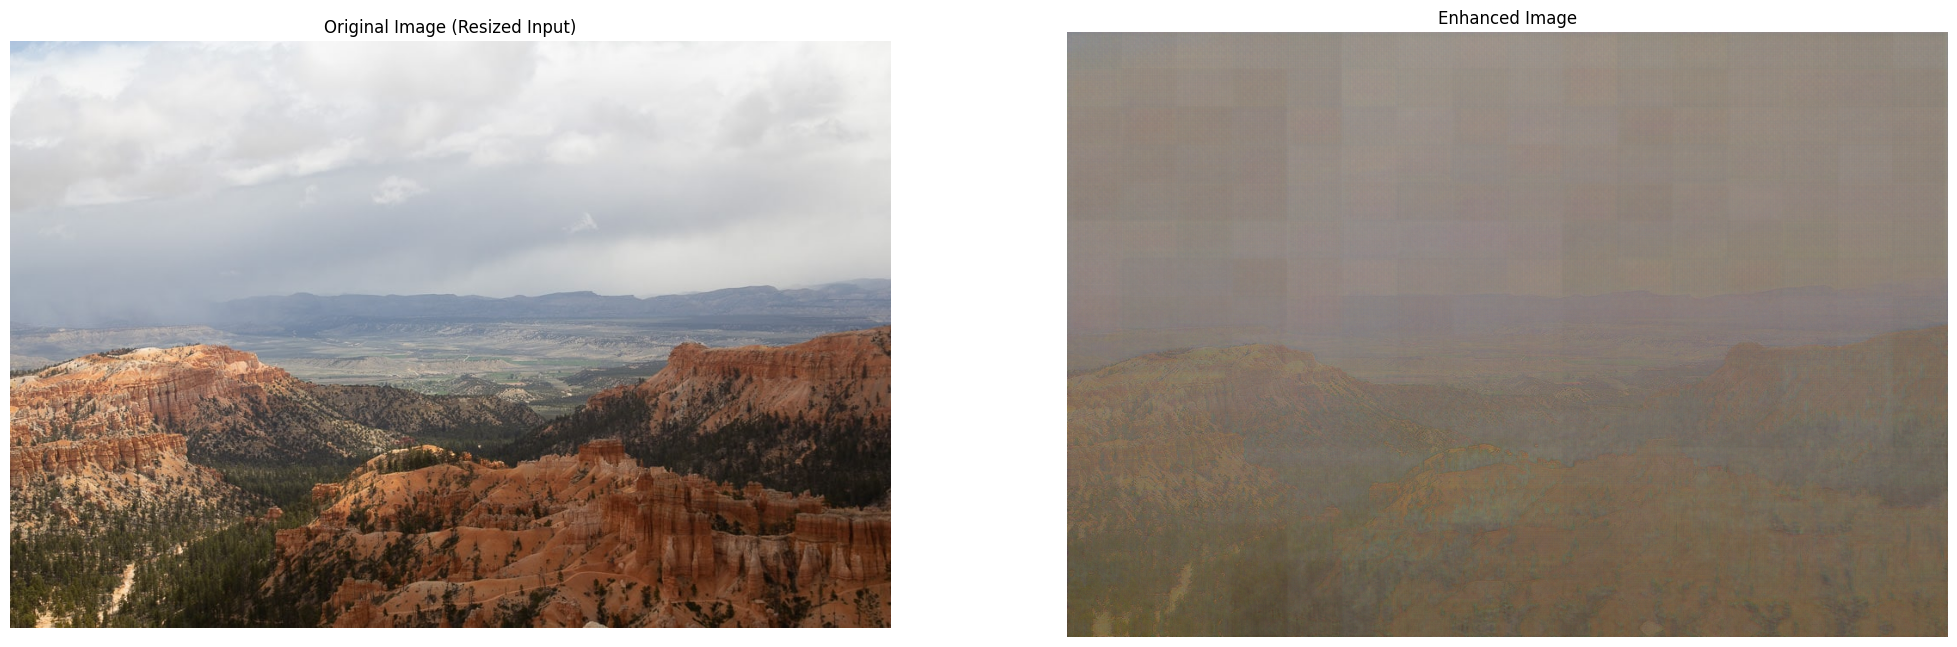

12.511551


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
from PIL import Image
from io import BytesIO


def resize(path, size):
    """Load and resize image preserving aspect ratio."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    img = Image.open(path).convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    return img.resize((new_w, new_h), Image.LANCZOS)

def pre_process(pil_img):
    """Prepare image for MAXIM (divisible by 64)."""
    w, h = pil_img.size
    # Resize to be multiple of 64 for MAXIM architecture requirements
    new_w = (w // 64) * 64
    new_h = (h // 64) * 64
    if new_w != w or new_h != h:
        pil_img = pil_img.resize((new_w, new_h), Image.LANCZOS)

    img = np.asarray(pil_img, dtype=np.float32) / 255.0
    img = np.expand_dims(img, axis=0) # Add batch dim
    return img, h, w, new_h, new_w

def make_shape_even(image):
  """Pad the image to have even shapes."""
  height, width = image.shape[0], image.shape[1]
  padh = 1 if height % 2 != 0 else 0
  padw = 1 if width % 2 != 0 else 0
  image = jnp.pad(image, [(0, padh), (0, padw), (0, 0)], mode='reflect')
  return image

def load_image(filepath):
    """Load and preprocess image."""
    img = Image.open(filepath).convert("RGB")
    img = np.asarray(img, np.float32) / 255.0
    return img

def pre_process_bytes(input_file):
  '''
  Pre-process the image before sending to the model
  '''
  input_img = load_image(input_file)
  # Padding images to have even shapes
  height, width = input_img.shape[0], input_img.shape[1]
  input_img = make_shape_even(input_img)
  height_even, width_even = input_img.shape[0], input_img.shape[1]

  # padding images to be multiplies of 64
  input_img = mod_padding_symmetric(input_img, factor=64)
  input_img = np.expand_dims(input_img, axis=0)

  return input_img, height, width, height_even, width_even

def predict(input_img):
    """Run inference using the global 'state'."""
    variables = {'params': state.params}
    if state.batch_stats is not None:
        variables['batch_stats'] = state.batch_stats

    # Forward pass (train=False)
    # The model returns (prediction, gates)
    prediction, gates = state.apply_fn(variables, input_img, train=False)
    return prediction

def post_process(pred, h_orig, w_orig, h_even, w_even):
    """Convert prediction back to PIL image."""
    pred = np.array(pred[0]) # Remove batch dim
    pred = np.clip(pred, 0.0, 1.0)
    pred = (pred * 255).astype(np.uint8)
    return Image.fromarray(pred)

# --- Main Execution ---
# path = "/content/gdrive/MyDrive/Facultad/tesis/test_imgs/IMG_6425.JPG"
path = False

# url = "https://phototraces.b-cdn.net/wp-content/uploads/2021/02/id_Free_RAW_Photos_for_Editing_09_Uneditedd.jpg"
url = "https://phototraces.b-cdn.net/wp-content/uploads/2021/03/Free_RAW_Photos_for_Editing_13_Unedited.jpg"

if path and os.path.exists(path):
    # 1. Load and Resize (Using 1280 to fit in Colab memory easily, adjust if needed)
    input_pil_img = resize(path, 1280)

    # 2. Preprocess
    input_img, h, w, h_even, w_even = pre_process(input_pil_img)

    # 3. Inference
    print("Running inference...")
    preds = predict(input_img)

    # 4. Post-process
    result = post_process(preds, h, w, h_even, w_even)

    # 5. Visualize
    f, ax = plt.subplots(1, 2, figsize=(25, 15))

    ax[0].imshow(input_pil_img)
    ax[0].set_title("Original Image (Resized Input)")
    ax[0].axis('off')

    ax[1].imshow(result)
    ax[1].set_title("Enhanced Image")
    ax[1].axis('off')

    plt.show()
elif url:
  image_bytes = BytesIO(requests.get(url).content)
  input_img, height, width, height_even, width_even = pre_process_bytes(image_bytes)
  preds = predict(input_img)
  result = post_process(preds, height, width, height_even, width_even)
  f, ax = plt.subplots(1, 2, figsize=(25, 15))

  ax[0].imshow(np.array(Image.open(image_bytes)))
  ax[0].set_title("Original Image (Resized Input)")
  ax[0].axis('off')

  ax[1].imshow(result)
  ax[1].set_title("Enhanced Image")
  ax[1].axis('off')

  plt.show()
  print(compute_psnr(preds[0], input_img))

else:
    print(f"Image not found: {path}, {url}")